## 1. 🏗️ Construction du pipeline EDS-NLP
Chargement et configuration du pipeline médical avec les composants 
de segmentation, normalisation, détection de dates et matching de termes cliniques.



In [1]:
import edsnlp

# Création du pipeline
nlp = edsnlp.blank("fr")
nlp.add_pipe("eds.sentences")
nlp.add_pipe("eds.normalizer")
nlp.add_pipe("eds.dates")
nlp.add_pipe("eds.matcher", config={
    "terms": {
        "cardiologie": ["douleurs thoraciques", "insuffisance cardiaque", "ECG"],
        "neurologie": ["migraine", "AVC", "épilepsie", "céphalées"],
        "pneumologie": ["toux", "dyspnée", "asthme", "bronchite"],
        "symptomes": ["douleur", "fièvre", "fatigue", "nausée"]
    }
})

print("✅ Pipeline EDS-NLP chargé avec succès !")


/Users/nourhtekam/Documents/M2-E3IN BIG Data & IA/Projet LAB/Ctd-IA/ctd-ia/venv/lib/python3.14/site-packages/confit/errors.py:18: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.error_wrappers import (


✅ Pipeline EDS-NLP chargé avec succès !


## 2. 🔍 Extraction des entités médicales
Analyse du texte clinique et identification des entités nommées 
(symptômes, pathologies) par spécialité médicale.


In [2]:
# Texte médical de test
texte = """
Le patient Jean Dupont, né le 12/03/1965, consulte le 20/01/2024 
pour des douleurs thoraciques depuis 3 jours. 
Il présente également de la fièvre à 38.5°C.
Antécédents : insuffisance cardiaque diagnostiquée en 2020.
"""

# On analyse le texte avec notre pipeline
doc = nlp(texte)

# On affiche les entités détectées
print("📋 Entités détectées :")
for ent in doc.ents:
    print(f"  → '{ent.text}' | Type : {ent.label_}")


📋 Entités détectées :
  → 'douleurs thoraciques' | Type : cardiologie
  → 'fièvre' | Type : symptomes
  → 'insuffisance cardiaque' | Type : cardiologie


## 3. 🔒 Anonymisation des données sensibles
Masquage des informations personnelles (noms, dates) à l'aide de spaCy 
et d'expressions régulières, conformément aux exigences RGPD.


In [3]:
import spacy
import re

nlp_spacy = spacy.load("fr_core_news_sm")

TERMES_MEDICAUX = [
    "LBBAP", "HTA", "BAV", "CRT", "ICD", "PM", "ECG",
    "PFA", "CSP", "EP", "ICM", "Brady", "Tachy",
    "Porteur", "Patient"
]

# ✅ NOUVEAU : mots jamais anonymisables
MOTS_EXCLUS = [
    "Antécédents", "Antecedents", "Procédure", "Indication",
    "Traitement", "Conclusion", "Résultat", "Discussion",
    "Contexte", "Diagnostic", "Histoire", "Suivi", "Bilan"
]

def anonymiser(texte: str) -> str:
    doc = nlp_spacy(texte)
    texte_anonyme = texte
    
    for ent in reversed(doc.ents):
        # Ignorer les termes médicaux
        if ent.text.upper() in [t.upper() for t in TERMES_MEDICAUX]:
            continue
        # ✅ Ignorer les mots exclus
        if ent.text in MOTS_EXCLUS or ent.text.rstrip(':') in MOTS_EXCLUS:
            continue
        
        if ent.label_ == "PER":
            texte_anonyme = texte_anonyme.replace(ent.text, "[PATIENT]")
        elif ent.label_ == "LOC":
            texte_anonyme = texte_anonyme.replace(ent.text, "[LIEU]")
        elif ent.label_ == "ORG":
            texte_anonyme = texte_anonyme.replace(ent.text, "[ORGANISATION]")
    
    texte_anonyme = re.sub(r'\d{2}/\d{2}/\d{4}', '[DATE]', texte_anonyme)
    texte_anonyme = re.sub(r'\d{2}/\d{4}', '[DATE]', texte_anonyme)
    texte_anonyme = re.sub(r'\b(19|20)\d{2}\b', '[DATE]', texte_anonyme)
    
    return texte_anonyme


## 4. Chargement du dataset FRASIMED

In [4]:
%pip install datasets


Note: you may need to restart the kernel to use updated packages.


In [5]:
from datasets import load_dataset

dataset = load_dataset("TypicaAI/MedicalNER_Fr")
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['sample_id', 'tokens', 'ner_tags', 'text', 'ner_tags_span'],
        num_rows: 16176
    })
})


In [6]:
# Afficher les 3 premiers exemples
for i in range(3):
    print(f"\n--- Exemple {i+1} ---")
    print("Texte :", dataset['train'][i]['text'])
    print("Entités :", dataset['train'][i]['ner_tags_span'])



--- Exemple 1 ---
Texte : atteint de poliomyélite dans son enfance il devient fan de blues en écoutant big joe turner .
Entités : [['Disease', 11, 23], ['PER', 77, 91]]

--- Exemple 2 ---
Texte : ruiné il parie avec howard stern de se faire ragrandir le pénis .
Entités : [['PER', 20, 32], ['AnatomicalStructure', 58, 63]]

--- Exemple 3 ---
Texte : en république dominicaine et en haïti la prévention du sida a constitué l’ un des principaux axes de travail .
Entités : [['LOC', 3, 25], ['LOC', 32, 37], ['Symptom', 55, 59]]


In [7]:
import os
os.environ["HF_TOKEN"] = "hf_xxxxxhf_pNrXrLwdMuqYEyKsvTcDPMNsOafcvrxQJCxxxxxxxxxxx"  # colle ton token ici


In [8]:
import os
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")


In [9]:
# Afficher les 3 premiers exemples
for i in range(3):
    print(f"\n--- Exemple {i+1} ---")
    print("Texte :", dataset['train'][i]['text'])
    print("Entités :", dataset['train'][i]['ner_tags_span'])



--- Exemple 1 ---
Texte : atteint de poliomyélite dans son enfance il devient fan de blues en écoutant big joe turner .
Entités : [['Disease', 11, 23], ['PER', 77, 91]]

--- Exemple 2 ---
Texte : ruiné il parie avec howard stern de se faire ragrandir le pénis .
Entités : [['PER', 20, 32], ['AnatomicalStructure', 58, 63]]

--- Exemple 3 ---
Texte : en république dominicaine et en haïti la prévention du sida a constitué l’ un des principaux axes de travail .
Entités : [['LOC', 3, 25], ['LOC', 32, 37], ['Symptom', 55, 59]]


## 5. 🔍 Exploration et analyse du dataset

In [10]:
import pandas as pd

# Convertir le dataset en DataFrame
df = pd.DataFrame(dataset['train'])

# Sauvegarder en CSV
df.to_csv("medicalner_fr.csv", index=False)

print(f"✅ {len(df)} lignes sauvegardées")
print("\n--- 5 premières lignes ---")
df.head()


✅ 16176 lignes sauvegardées

--- 5 premières lignes ---


,sample_id,tokens,ner_tags,text,ner_tags_span
0,f5ce4a43-24f0-4bd2-8dce-7faa41342795,"[atteint, de, poliomyélite, dans, son, enfance...","[O, O, B-Disease, O, O, O, O, O, O, O, O, O, O...",atteint de poliomyélite dans son enfance il de...,"[['Disease', 11, 23], ['PER', 77, 91]]"
1,0b89670f-98a7-4695-9940-ca50a983e76d,"[ruiné, il, parie, avec, howard, stern, de, se...","[O, O, O, O, B-PER, I-PER, O, O, O, O, O, B-An...",ruiné il parie avec howard stern de se faire r...,"[['PER', 20, 32], ['AnatomicalStructure', 58, ..."
2,5a96d0ce-88ae-41e2-9767-64720fed6e15,"[en, république, dominicaine, et, en, haïti, l...","[O, B-LOC, I-LOC, O, O, B-LOC, O, O, O, B-Symp...",en république dominicaine et en haïti la préve...,"[['LOC', 3, 25], ['LOC', 32, 37], ['Symptom', ..."
3,948e62fd-e071-42fc-8cd4-277c71fd4770,"[gonarthrose, (, arthrose, du, genou, ), d, ap...","[B-Disease, O, O, O, O, O, O, O, O, B-CW, I-CW...",gonarthrose ( arthrose du genou ) d après la c...,"[['Disease', 0, 11], ['CW', 45, 87]]"
4,7e9f8f06-2eba-49d9-b425-8c41d9f9e95f,"[hernie, abdominale, non, précisée, d, après, ...","[B-Disease, I-Disease, O, O, O, O, O, B-CW, I-...",hernie abdominale non précisée d après la clas...,"[['Disease', 0, 17], ['CW', 42, 84]]"


In [11]:
# Infos générales
print("=== STRUCTURE ===")
print(df.info())

print("\n=== DIMENSIONS ===")
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")

print("\n=== COLONNES ===")
print(df.columns.tolist())

print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

print("\n=== APERÇU STATISTIQUE ===")
print(df.describe())


=== STRUCTURE ===
<class 'pandas.DataFrame'>
RangeIndex: 16176 entries, 0 to 16175
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sample_id      16176 non-null  str   
 1   tokens         16176 non-null  object
 2   ner_tags       16176 non-null  object
 3   text           16176 non-null  str   
 4   ner_tags_span  16176 non-null  str   
dtypes: object(2), str(3)
memory usage: 3.2+ MB
None

=== DIMENSIONS ===
Lignes : 16176 | Colonnes : 5

=== COLONNES ===
['sample_id', 'tokens', 'ner_tags', 'text', 'ner_tags_span']

=== VALEURS MANQUANTES ===
sample_id        0
tokens           0
ner_tags         0
text             0
ner_tags_span    0
dtype: int64

=== APERÇU STATISTIQUE ===
                                   sample_id  \
count                                  16176   
unique                                 16176   
top     f5ce4a43-24f0-4bd2-8dce-7faa41342795   
freq                                       1  

In [12]:
# Afficher un exemple lisible
print("=== EXEMPLE COMPLET ===")
print("Texte :", df['text'][0])
print("\nEntités détectées :", df['ner_tags_span'][0])


=== EXEMPLE COMPLET ===
Texte : atteint de poliomyélite dans son enfance il devient fan de blues en écoutant big joe turner .

Entités détectées : [['Disease', 11, 23], ['PER', 77, 91]]


In [13]:
import ast
from collections import Counter

# Compter tous les types d'entités
all_entities = []
for span in df['ner_tags_span']:
    entities = ast.literal_eval(span)
    for ent in entities:
        all_entities.append(ent[0])

# Afficher la distribution
counter = Counter(all_entities)
print("=== DISTRIBUTION DES ENTITÉS ===")
for entity, count in counter.most_common():
    print(f"{entity:25} : {count}")


=== DISTRIBUTION DES ENTITÉS ===
AnatomicalStructure       : 4685
Disease                   : 4658
Medication/Vaccine        : 4226
MedicalProcedure          : 3170
Symptom                   : 1763
LOC                       : 525
PER                       : 521
PROD                      : 305
CW                        : 167
ORG                       : 83
GRP                       : 14


In [14]:
# Appliquer l'anonymisation sur tout le dataset
df['text_anonymise'] = df['text'].apply(anonymiser)
print("✅ Anonymisation terminée !")
df[['text', 'text_anonymise']].head()


✅ Anonymisation terminée !


,text,text_anonymise
0,atteint de poliomyélite dans son enfance il de...,atteint de poliomyélite dans son enfance il de...
1,ruiné il parie avec howard stern de se faire r...,ruiné il parie avec [PATIENT] de se faire ragr...
2,en république dominicaine et en haïti la préve...,en [LIEU] et en haïti la prévention du sida a ...
3,gonarthrose ( arthrose du genou ) d après la c...,gonarthrose ( arthrose du genou ) d après la c...
4,hernie abdominale non précisée d après la clas...,hernie abdominale non précisée d après la clas...


In [15]:
# Afficher les exemples un par un, lisiblement
for i in range(5):
    print(f"\n{'='*60}")
    print(f"EXEMPLE {i+1}")
    print(f"{'='*60}")
    print(f"📄 ORIGINAL :\n{df['text'][i]}")
    print(f"\n🔒 ANONYMISÉ :\n{df['text_anonymise'][i]}")



EXEMPLE 1
📄 ORIGINAL :
atteint de poliomyélite dans son enfance il devient fan de blues en écoutant big joe turner .

🔒 ANONYMISÉ :
atteint de poliomyélite dans son enfance il devient fan de blues en écoutant [PATIENT] .

EXEMPLE 2
📄 ORIGINAL :
ruiné il parie avec howard stern de se faire ragrandir le pénis .

🔒 ANONYMISÉ :
ruiné il parie avec [PATIENT] de se faire ragrandir le pénis .

EXEMPLE 3
📄 ORIGINAL :
en république dominicaine et en haïti la prévention du sida a constitué l’ un des principaux axes de travail .

🔒 ANONYMISÉ :
en [LIEU] et en haïti la prévention du sida a constitué l’ un des principaux axes de travail .

EXEMPLE 4
📄 ORIGINAL :
gonarthrose ( arthrose du genou ) d après la classification internationale des maladies .

🔒 ANONYMISÉ :
gonarthrose ( arthrose du genou ) d après la classification internationale des maladies .

EXEMPLE 5
📄 ORIGINAL :
hernie abdominale non précisée d après la classification internationale des maladies ;

🔒 ANONYMISÉ :
hernie abdominale no

In [16]:
modifies = (df['text'] != df['text_anonymise']).sum()
print(f"✅ Textes modifiés  : {modifies}")
print(f"📄 Total           : {len(df)}")
print(f"📊 Taux            : {modifies/len(df)*100:.1f}%")


✅ Textes modifiés  : 2892
📄 Total           : 16176
📊 Taux            : 17.9%


## 6. 💾 Sauvegarde du dataset anonymisé

In [17]:
df.to_csv("medicalner_fr_anonymise.csv", index=False)
print(f"✅ Dataset anonymisé sauvegardé !")


✅ Dataset anonymisé sauvegardé !


## 7. 🏷️ Classification par Topic médical

In [18]:
# Dictionnaire de mots-clés par Topic
topics_keywords = {
    "Brady"  : ["stimulateur", "pacemaker", "bradycardie", "bloc auriculo", "BAV"],
    "Tachy"  : ["défibrillateur", "ICD", "tachycardie", "fibrillation", "flutter"],
    "CRT"    : ["resynchronisation", "CRT", "insuffisance cardiaque", "fraction éjection"],
    "EP"     : ["ablation", "électrophysiologie", "cathéter", "arythmie"],
    "ICM"    : ["holter", "ICM", "moniteur implantable", "syncope"],
    "PFA"    : ["électroporation", "PFA", "champ pulsé"],
    "CSP"    : ["his", "LBBAP", "septum", "conduction"],
}

# ✅ Noms complets
TOPICS_LABELS = {
    "Brady"  : "Bradycardie",
    "Tachy"  : "Tachycardie",
    "CRT"    : "Resynchronisation cardiaque",
    "EP"     : "Électrophysiologie",
    "ICM"    : "Moniteur implantable",
    "PFA"    : "Électroporation (PFA)",
    "CSP"    : "Conduction His/LBBAP",
    "Others" : "Autre",
}

def classifier_topic(texte):
    texte_lower = texte.lower()
    for topic, keywords in topics_keywords.items():
        for kw in keywords:
            if kw.lower() in texte_lower:
                return TOPICS_LABELS[topic]  # ✅ retourne le nom complet
    return TOPICS_LABELS["Others"]

# Appliquer sur tout le dataset
df['topic'] = df['text_anonymise'].apply(classifier_topic)
print(df['topic'].value_counts())


topic
Autre                          15966
Conduction His/LBBAP             127
Électrophysiologie                43
Tachycardie                       18
Bradycardie                       14
Resynchronisation cardiaque        5
Électroporation (PFA)              2
Moniteur implantable               1
Name: count, dtype: int64


## Étape 8 : Visualisation de la distribution

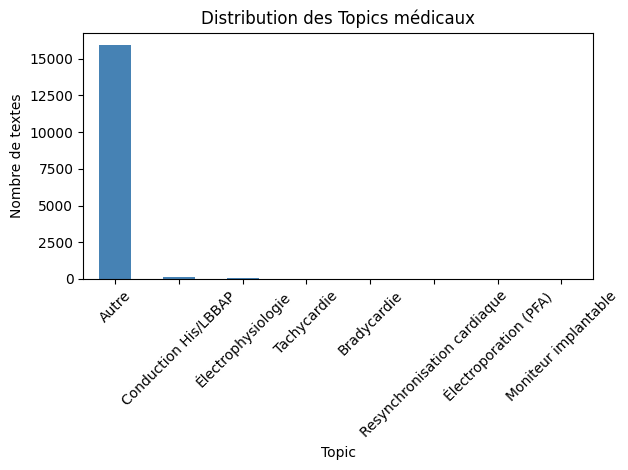

✅ Graphique sauvegardé !


In [19]:
import matplotlib.pyplot as plt

df['topic'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Distribution des Topics médicaux")
plt.xlabel("Topic")
plt.ylabel("Nombre de textes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("distribution_topics.png")
plt.show()
print("✅ Graphique sauvegardé !")


## 9. 🏷️ Suggestion automatique de #tags


In [20]:
def suggerer_hashtags(texte):
    """Extrait les entités médicales comme #tags via spaCy + mots-clés"""
    
    # Entités détectées par spaCy
    doc = nlp_spacy(texte)
    hashtags = []
    
    # Ajouter les maladies/symptômes détectés par NER
    for ent in doc.ents:
        if ent.label_ in ["Disease", "Symptom", "MedicalProcedure"]:
            tag = "#" + ent.text.replace(" ", "_").lower()
            hashtags.append(tag)
    
    # Ajouter le Topic comme #tag
    topic = classifier_topic(texte)
    if topic != "Others":
        hashtags.append(f"#{topic}")
    
    # Ajouter les mots-clés médicaux trouvés dans le texte
    mots_medicaux = [
        "pacemaker", "défibrillateur", "ablation", "arythmie",
        "fibrillation", "tachycardie", "bradycardie", "insuffisance cardiaque",
        "stimulateur", "cathéter", "holter", "syncope"
    ]
    for mot in mots_medicaux:
        if mot in texte.lower():
            hashtags.append(f"#{mot.replace(' ', '_')}")
    
    return list(set(hashtags)) if hashtags else ["#médecine_générale"]

# Tester sur un cas rythmologique réel
post_test = "Patient de 72 ans avec BAV du 3ème degré, implantation pacemaker LBBAP, insuffisance cardiaque."
print("🏷️ #tags :", suggerer_hashtags(post_test))


🏷️ #tags : ['#Bradycardie', '#pacemaker', '#insuffisance_cardiaque']


## 10. 🔘 Simulation du bouton "Pré-soumettre"


In [21]:
def generer_resume(texte_anon):
    lignes = [l.strip() for l in texte_anon.strip().split('\n') if l.strip()]
    
    indication, procedure, resultat, antecedents = "", "", "", ""
    
    for ligne in lignes:
        l = ligne.lower()
        
        if any(mot in l for mot in ['bav', 'fibrillation', 'tachycardie', 'bloc', 'fa ', 'porteur']):
            if not indication:
                indication = ligne
        
        if any(mot in l for mot in ['implantation', 'ablation', 'cardioversion', 'pacemaker', 'défibrillateur', 'crt', 'lbbap']):
            procedure = ligne
        
        if any(mot in l for mot in ['complication', 'succès', 'résultat', 'suivi', 'sortie', 'sans']):
            resultat = ligne
        
        if any(mot in l for mot in ['antécédents', 'antecedents', 'atcd', 'terrain']):
            antecedents = ligne
    
    resume = ""
    if indication  : resume += f"📌 Indication  : {indication}\n"
    if antecedents :
        contenu = re.sub(r'^antécédents\s*:\s*', '', antecedents, flags=re.IGNORECASE).strip()
        resume += f"🩺 Antécédents : {contenu}\n"
    if procedure   : resume += f"🔧 Procédure   : {procedure}\n"
    if resultat    : resume += f"✅ Résultat    : {resultat}\n"
    
    return resume if resume else texte_anon[:200] + "..."


In [22]:
def generer_titre(texte_anon):
    """Génère un titre médical pertinent"""
    
    topic = classifier_topic(texte_anon)
    
    # Extraire l'âge
    age = ""
    age_match = re.search(r'(\d+)\s*ans', texte_anon)
    if age_match:
        age = f"Patient de {age_match.group(1)} ans"
    
    # Extraire la procédure principale
    procedures = {
        "pacemaker"     : "implantation de pacemaker",
        "défibrillateur": "implantation de défibrillateur",
        "ablation"      : "procédure d'ablation",
        "LBBAP"         : "implantation LBBAP",
        "CRT"           : "resynchronisation cardiaque",
    }
    procedure = ""
    for mot, description in procedures.items():
        if mot.lower() in texte_anon.lower():
            procedure = description
            break
    
    # Construire le titre
    if age and procedure:
        return f"{age} — {procedure} ({topic})"
    elif procedure:
        return f"Cas clinique : {procedure} ({topic})"
    elif age:
        return f"{age} — Cas {topic}"
    else:
        return f"Cas clinique rythmologique — {topic}"


def pre_soumettre(texte_brut):
    print("⏳ L'IA analyse votre post...\n")
    print("="*60)
    
    texte_anon = anonymiser(texte_brut)
    print("🔒 TEXTE ANONYMISÉ :")
    print(texte_anon)
    
    topic = classifier_topic(texte_anon)
    print(f"\n📂 TOPIC SUGGÉRÉ : {topic}")
    
    tags = suggerer_hashtags(texte_anon)
    print(f"\n🏷️  #TAGS SUGGÉRÉS : {tags}")
    
    titre = generer_titre(texte_anon)
    print(f"\n📝 TITRE SUGGÉRÉ : {titre}")
    
    resume = generer_resume(texte_anon)
    print(f"\n📋 RÉSUMÉ : {resume}")
    
    print("\n" + "="*60)
    print("✅ Vérifiez et cliquez sur Soumettre !")


# Test
post_test = """
Patient de 72 ans, Jean Martin, né le 12/01/1954.
Porteur d'un BAV du 3ème degré.
Implantation d'un pacemaker LBBAP le 15/03/2026.
Antécédents : insuffisance cardiaque, HTA.
Procédure réalisée sans complication.
"""

pre_soumettre(post_test)


⏳ L'IA analyse votre post...

🔒 TEXTE ANONYMISÉ :

Patient de 72 ans, [PATIENT], né le [DATE].
Porteur d'un BAV du 3ème degré.
Implantation d'un pacemaker LBBAP le [DATE].
Antécédents : insuffisance cardiaque, HTA.
Procédure réalisée sans complication.


📂 TOPIC SUGGÉRÉ : Bradycardie

🏷️  #TAGS SUGGÉRÉS : ['#Bradycardie', '#pacemaker', '#insuffisance_cardiaque']

📝 TITRE SUGGÉRÉ : Patient de 72 ans — implantation de pacemaker (Bradycardie)

📋 RÉSUMÉ : 📌 Indication  : Porteur d'un BAV du 3ème degré.
🩺 Antécédents : insuffisance cardiaque, HTA.
🔧 Procédure   : Implantation d'un pacemaker LBBAP le [DATE].
✅ Résultat    : Procédure réalisée sans complication.


✅ Vérifiez et cliquez sur Soumettre !


In [23]:
%pip install transformers sentencepiece sacremoses


Note: you may need to restart the kernel to use updated packages.


In [24]:
%pip install torch


  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
Using cached setuptools-81.0.0-py3-none-any.whl (1.1 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools None
    Uninstalling setuptools-None:
      Successfully uninstalled setuptools-None
Note: you may need to restart the kernel to use updated packages.


In [25]:
from transformers import MarianMTModel, MarianTokenizer

def traduire(texte: str, src: str = "fr", tgt: str = "en") -> str:
    """
    Traduit un texte médical avec MarianMT.
    src: langue source ('fr' ou 'en')
    tgt: langue cible ('en' ou 'fr')
    """
    model_name = f"Helsinki-NLP/opus-mt-{src}-{tgt}"
    tokenizer = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name)

    inputs = tokenizer([texte], return_tensors="pt", padding=True, truncation=True, max_length=512)
    translated = model.generate(**inputs)
    return tokenizer.decode(translated[0], skip_special_tokens=True)


# Test FR → EN
texte_fr = "Patient de 72 ans, porteur d'un BAV du 3ème degré. Implantation d'un pacemaker LBBAP réalisée sans complication."
print("🇫🇷 Original :", texte_fr)
print("🇬🇧 Traduit  :", traduire(texte_fr, src="fr", tgt="en"))

print()

# Test EN → FR
texte_en = "70-year-old male with persistent AF. Redo PVI ablation performed with EnsiteX. First pass efficacy achieved."
print("🇬🇧 Original :", texte_en)
print("🇫🇷 Traduit  :", traduire(texte_en, src="en", tgt="fr"))


🇫🇷 Original : Patient de 72 ans, porteur d'un BAV du 3ème degré. Implantation d'un pacemaker LBBAP réalisée sans complication.


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

🇬🇧 Traduit  : 72-year-old patient, carrying a 3rd degree BAV. Implementation of a LBBAP pacemaker without complications.

🇬🇧 Original : 70-year-old male with persistent AF. Redo PVI ablation performed with EnsiteX. First pass efficacy achieved.


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

🇫🇷 Traduit  : Homme de 70 ans avec une AF persistante. Redo PVI ablation effectuée avec EnsiteX. Premier passage d'efficacité atteint.


In [26]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Zone de saisie
texte_input = widgets.Textarea(
    placeholder='Collez votre post clinique ici...',
    layout=widgets.Layout(width='100%', height='150px')
)

# Bouton
bouton = widgets.Button(
    description='🔍 Analyser & Soumettre',
    button_style='primary',
    layout=widgets.Layout(width='250px', height='40px')
)

# Zone de résultat
output = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        texte = texte_input.value.strip()
        if not texte:
            print("⚠️ Veuillez saisir un texte avant de soumettre.")
            return
        pre_soumettre(texte)

bouton.on_click(on_click)

# Affichage
display(widgets.VBox([
    widgets.HTML("<h3>📋 Nouveau post clinique</h3>"),
    texte_input,
    bouton,
    output
]))
